In [1]:
# CRIME MAPPING & PREDICTION SYSTEM
# GIS Spatial Analysis of Kidnapping Hotspots in Nigeria

# IMPORT LIBRARIES

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np




In [4]:
# LOAD DATASET

# Load the dataset you uploaded
data = pd.read_csv("combined.csv")

# Preview dataset
print(data.head())




         Date    State     LGA   Latitude  Longitude  Victims Incident_Type  \
0  2024-04-01   Kaduna  Chikun  10.464406   7.445945       52        School   
1  2025-02-17  Katsina   Jibia  12.979452   7.205360       75        School   
2  2023-08-11  Zamfara   Zurmi  12.545869   6.788208       24        Church   
3  2021-03-22  Katsina   Jibia  13.050956   7.203742       30        School   
4  2025-09-14   Kaduna   Igabi  10.863119   7.706936       21       Village   

  Time_of_Day Severity  Cluster_Label  
0     Evening     High              1  
1   Afternoon     High              1  
2     Morning   Medium              1  
3   Afternoon   Medium              1  
4   Afternoon   Medium              1  


In [5]:
# CONVERT DATA INTO GEOSPATIAL FORMAT


# GeoPandas converts latitude and longitude into spatial points
gdf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data.Longitude, data.Latitude)
)

print(gdf.head())




         Date    State     LGA   Latitude  Longitude  Victims Incident_Type  \
0  2024-04-01   Kaduna  Chikun  10.464406   7.445945       52        School   
1  2025-02-17  Katsina   Jibia  12.979452   7.205360       75        School   
2  2023-08-11  Zamfara   Zurmi  12.545869   6.788208       24        Church   
3  2021-03-22  Katsina   Jibia  13.050956   7.203742       30        School   
4  2025-09-14   Kaduna   Igabi  10.863119   7.706936       21       Village   

  Time_of_Day Severity  Cluster_Label                  geometry  
0     Evening     High              1  POINT (7.44595 10.46441)  
1   Afternoon     High              1  POINT (7.20536 12.97945)  
2     Morning   Medium              1  POINT (6.78821 12.54587)  
3   Afternoon   Medium              1  POINT (7.20374 13.05096)  
4   Afternoon   Medium              1  POINT (7.70694 10.86312)  


<Figure size 1000x800 with 0 Axes>

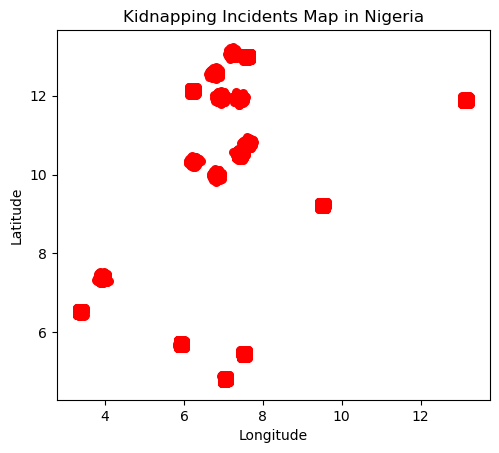

In [6]:
# VISUALIZE KIDNAPPING INCIDENTS


plt.figure(figsize=(10,8))

gdf.plot(
    marker="o",
    color="red",
    markersize=30
)

plt.title("Kidnapping Incidents Map in Nigeria")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()



In [7]:

# HOTSPOT DETECTION (KERNEL DENSITY)
# Extract coordinates
coords = data[["Latitude","Longitude"]]

coords_array = np.array(coords)

# Create Kernel Density model
kde = KernelDensity(bandwidth=0.3)

# Fit model
kde.fit(coords_array)

# Calculate density score
density = kde.score_samples(coords_array)

# Add density column
data["crime_density"] = density

print(data[["State","LGA","crime_density"]].head())




     State     LGA  crime_density
0   Kaduna  Chikun      -1.315990
1  Katsina   Jibia      -1.995491
2  Zamfara   Zurmi      -1.955923
3  Katsina   Jibia      -2.009771
4   Kaduna   Igabi      -1.682198


In [8]:
# CLASSIFY RISK LEVEL

def risk_level(score):

    if score > -1:
        return "High"

    elif score > -3:
        return "Medium"

    else:
        return "Low"

data["Risk_Level"] = data["crime_density"].apply(risk_level)




In [9]:
# FEATURE ENGINEERING
# Convert categorical features to numeric

data_encoded = pd.get_dummies(
    data,
    columns=["State","Incident_Type","Time_of_Day","Severity"],
    drop_first=True
)


# PREPARE MACHINE LEARNING DATA
# Features
X = data_encoded.drop(["Risk_Level","Date","LGA","geometry"], axis=1, errors="ignore")

# Target variable
y = data["Risk_Level"]




In [10]:
# SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# TRAIN MACHINE LEARNING MODEL

model = RandomForestClassifier()

model.fit(X_train, y_train)


# PREDICT CRIME RISK
predictions = model.predict(X_test)

print("Predictions:")
print(predictions)




Predictions:
['Medium' 'Medium' 'Medium' ... 'Medium' 'Medium' 'Medium']


In [12]:
# SAVE TRAINED MODEL
import joblib

# Save the trained model
joblib.dump(model, "crime_model.pkl")

print("Model saved successfully as crime_model.pkl")

Model saved successfully as crime_model.pkl


In [13]:
# Save feature order used during training
feature_order = X.columns.tolist()

joblib.dump(feature_order, "feature_order.pkl")

['feature_order.pkl']

In [14]:
# ENCODE CATEGORICAL FEATURES


label_encoders = {}

categorical_columns = [
    "State",
    "Incident_Type",
    "Time_of_Day",
    "Severity"
]

for col in categorical_columns:
    
    le = LabelEncoder()
    
    data[col] = le.fit_transform(data[col])
    
    label_encoders[col] = le


# Save encoders
joblib.dump(label_encoders, "encoders.pkl")

print("Encoders saved as encoders.pkl")

Encoders saved as encoders.pkl


In [19]:
# SCALE NUMERICAL FEATURES


scaler = StandardScaler()

numerical_columns = [
    "Latitude",
    "Longitude",
    "Victims"
]

data[numerical_columns] = scaler.fit_transform(data[numerical_columns])


# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


<Figure size 1000x800 with 0 Axes>

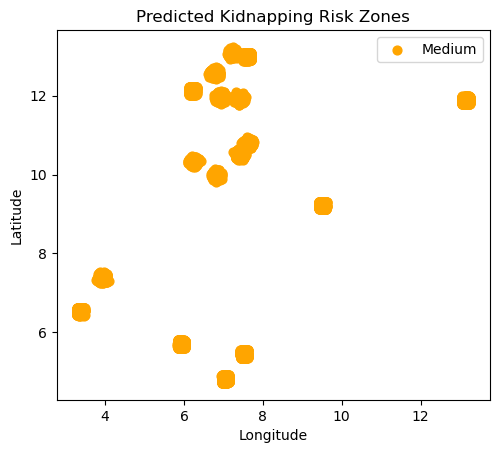

Predicted_Risk
Medium    10000
Name: count, dtype: int64
Crime prediction results saved.


In [16]:
# PREDICT RISK FOR ALL LOCATIONS

#data["Predicted_Risk"] = model.predict(X)

# Predict risk
data["Predicted_Risk"] = model.predict(X)

# Recreate GeoDataFrame with updated data
gdf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data.Longitude, data.Latitude)
)

# VISUALIZE PREDICTED RISK

# Risk colors
colors = {
    "High": "red",
    "Medium": "orange",
    "Low": "green"
}

plt.figure(figsize=(10,8))

for risk, color in colors.items():

    subset = gdf[gdf["Predicted_Risk"] == risk]

    # Plot only if data exists
    if not subset.empty:
        subset.plot(
            marker="o",
            color=color,
            label=risk,
            markersize=40
        )

plt.title("Predicted Kidnapping Risk Zones")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()

plt.show()

print(data["Predicted_Risk"].value_counts())

# SAVE RESULTS

data.to_csv("crime_prediction_results.csv", index=False)

print("Crime prediction results saved.")

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# -----------------------------
# Example placeholders
# Replace with your real data
# -----------------------------
y_true = [0, 1, 1, 0, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1, 1, 1]

# -----------------------------
# Accuracy (overall correctness)
# -----------------------------
accuracy = accuracy_score(y_true, y_pred)

# -----------------------------
# Effectiveness Metrics
# -----------------------------
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Confusion Matrix (very important for effectiveness)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# Effectiveness score (custom idea)
# Measures how well the model avoids wrong predictions
effectiveness = (tp + tn) / (tp + tn + fp + fn)

# -----------------------------
# Output Results
# -----------------------------
print("=== Model Performance ===\n")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Effectiveness Score: {effectiveness:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred))

=== Model Performance ===

Accuracy: 0.7143
Precision: 0.7500
Recall (Sensitivity): 0.7500
F1 Score: 0.7500
Effectiveness Score: 0.7143

Confusion Matrix:
[[2 1]
 [1 3]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.75      0.75      0.75         4

    accuracy                           0.71         7
   macro avg       0.71      0.71      0.71         7
weighted avg       0.71      0.71      0.71         7

